In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset
df = pd.read_csv("synthetic_blood_profile_dataset.csv")

# Display first rows
df.head()

,Patient_ID,Age,Gender,Hemoglobin (g/dL),WBC (10^3/uL),RBC (million/uL),Platelets (10^3/uL),MCV (fL),MCH (pg),MCHC (g/dL),RDW (%)
0,P_0001,32,Male,13.65,10.77,4.36,429.44,96.68,30.87,34.91,13.77
1,P_0002,21,Female,17.62,5.55,5.05,177.94,89.45,30.63,32.36,12.43
2,P_0003,53,Male,16.35,7.96,6.09,239.79,93.08,31.93,34.54,13.16
3,P_0004,49,Female,12.68,10.56,5.85,260.57,97.85,27.55,35.11,13.42
4,P_0005,46,Male,16.86,4.98,4.52,263.68,88.34,27.30,33.38,11.60


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           1000 non-null   str    
 1   Age                  1000 non-null   int64  
 2   Gender               1000 non-null   str    
 3   Hemoglobin (g/dL)    1000 non-null   float64
 4   WBC (10^3/uL)        1000 non-null   float64
 5   RBC (million/uL)     1000 non-null   float64
 6   Platelets (10^3/uL)  1000 non-null   float64
 7   MCV (fL)             1000 non-null   float64
 8   MCH (pg)             1000 non-null   float64
 9   MCHC (g/dL)          1000 non-null   float64
 10  RDW (%)              1000 non-null   float64
dtypes: float64(8), int64(1), str(2)
memory usage: 96.9 KB


In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numeric values
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

df.head()

,Patient_ID,Age,Gender,Hemoglobin (g/dL),WBC (10^3/uL),RBC (million/uL),Platelets (10^3/uL),MCV (fL),MCH (pg),MCHC (g/dL),RDW (%)
0,P_0001,32,Male,13.65,10.77,4.36,429.44,96.68,30.87,34.91,13.77
1,P_0002,21,Female,17.62,5.55,5.05,177.94,89.45,30.63,32.36,12.43
2,P_0003,53,Male,16.35,7.96,6.09,239.79,93.08,31.93,34.54,13.16
3,P_0004,49,Female,12.68,10.56,5.85,260.57,97.85,27.55,35.11,13.42
4,P_0005,46,Male,16.86,4.98,4.52,263.68,88.34,27.30,33.38,11.60


In [5]:
# Select numerical laboratory measurements
blood_features = df.select_dtypes(include=['int64','float64'])

blood_features.head()

,Age,Hemoglobin (g/dL),WBC (10^3/uL),RBC (million/uL),Platelets (10^3/uL),MCV (fL),MCH (pg),MCHC (g/dL),RDW (%)
0,32,13.65,10.77,4.36,429.44,96.68,30.87,34.91,13.77
1,21,17.62,5.55,5.05,177.94,89.45,30.63,32.36,12.43
2,53,16.35,7.96,6.09,239.79,93.08,31.93,34.54,13.16
3,49,12.68,10.56,5.85,260.57,97.85,27.55,35.11,13.42
4,46,16.86,4.98,4.52,263.68,88.34,27.30,33.38,11.60


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(blood_features)

X_scaled.shape

(1000, 9)

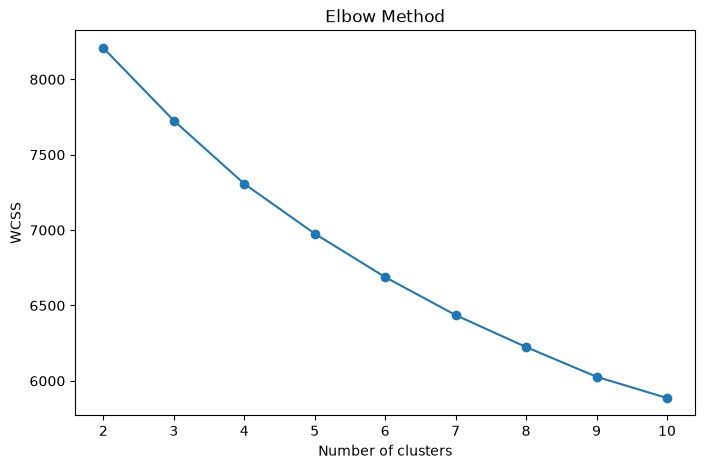

In [7]:
wcss = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Blood_Profile_Cluster"] = clusters

df.head()

,Patient_ID,Age,Gender,Hemoglobin (g/dL),WBC (10^3/uL),RBC (million/uL),Platelets (10^3/uL),MCV (fL),MCH (pg),MCHC (g/dL),RDW (%),Blood_Profile_Cluster
0,P_0001,32,Male,13.65,10.77,4.36,429.44,96.68,30.87,34.91,13.77,1
1,P_0002,21,Female,17.62,5.55,5.05,177.94,89.45,30.63,32.36,12.43,2
2,P_0003,53,Male,16.35,7.96,6.09,239.79,93.08,31.93,34.54,13.16,1
3,P_0004,49,Female,12.68,10.56,5.85,260.57,97.85,27.55,35.11,13.42,1
4,P_0005,46,Male,16.86,4.98,4.52,263.68,88.34,27.30,33.38,11.60,2


In [9]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.07527966091006867


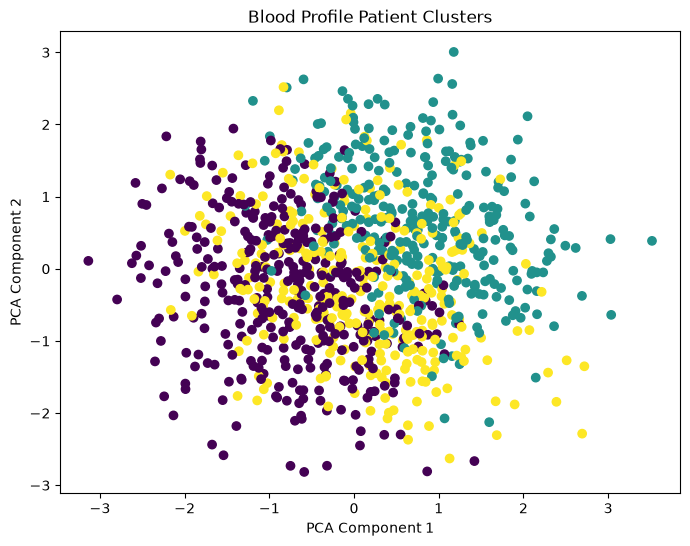

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("Blood Profile Patient Clusters")

plt.show()

In [11]:
text_columns = df.select_dtypes(
    include=['object']
).columns

text_columns

Index(['Patient_ID', 'Gender'], dtype='str')

In [12]:
# Choose first text column
text_column = text_columns[0]

texts = df[text_column].astype(str)

texts.head()

0    P_0001
1    P_0002
2    P_0003
3    P_0004
4    P_0005
Name: Patient_ID, dtype: str

In [13]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=500
)

X_text = tfidf.fit_transform(texts)

X_text.shape

(1000, 500)

In [14]:
text_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

text_clusters = text_kmeans.fit_predict(
    X_text
)


df["Text_Cluster"] = text_clusters

df.head()

,Patient_ID,Age,Gender,Hemoglobin (g/dL),WBC (10^3/uL),RBC (million/uL),Platelets (10^3/uL),MCV (fL),MCH (pg),MCHC (g/dL),RDW (%),Blood_Profile_Cluster,Text_Cluster
0,P_0001,32,Male,13.65,10.77,4.36,429.44,96.68,30.87,34.91,13.77,1,0
1,P_0002,21,Female,17.62,5.55,5.05,177.94,89.45,30.63,32.36,12.43,2,0
2,P_0003,53,Male,16.35,7.96,6.09,239.79,93.08,31.93,34.54,13.16,1,0
3,P_0004,49,Female,12.68,10.56,5.85,260.57,97.85,27.55,35.11,13.42,1,0
4,P_0005,46,Male,16.86,4.98,4.52,263.68,88.34,27.30,33.38,11.60,2,0


In [15]:
terms = tfidf.get_feature_names_out()

for i, center in enumerate(text_kmeans.cluster_centers_):
    
    print("\nCluster:", i)
    
    words = center.argsort()[-10:]
    
    print(
        [terms[j] for j in words]
    )


Cluster: 0
['p_0664', 'p_0663', 'p_0662', 'p_0661', 'p_0660', 'p_0659', 'p_0658', 'p_0657', 'p_0670', 'p_0998']

Cluster: 1
['p_0662', 'p_0661', 'p_0660', 'p_0659', 'p_0658', 'p_0657', 'p_0656', 'p_0654', 'p_0998', 'p_0974']

Cluster: 2
['p_0664', 'p_0663', 'p_0662', 'p_0661', 'p_0660', 'p_0659', 'p_0658', 'p_0657', 'p_0670', 'p_0576']


In [16]:
cluster_summary = df.groupby(
    [
        "Blood_Profile_Cluster",
        "Text_Cluster"
    ]
).size()


cluster_summary

Blood_Profile_Cluster  Text_Cluster
0                      0               363
                       1                 1
1                      0               313
2                      0               322
                       2                 1
dtype: int64

In [17]:
df.to_csv(
    "synthetic_blood_profile_clustered.csv",
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully
